# Returns to College Education on Income — Adult Census Income (DML)

**Dataset:** [UCI Adult / "Census Income"](https://archive.ics.uci.edu/dataset/2/adult) — 48,842 individuals from the 1994 US Census, donated by Barry Becker.

**Research question:** does holding a college degree causally raise the probability of earning more than \$50K/year, once we adjust for the demographic and labor-market factors that jointly drive both who gets a degree and who earns well?

| Role | Variable | Definition |
|---|---|---|
| Treatment $D$ | `college_degree` | `education-num >= 13` (Bachelors, Masters, Prof-school, Doctorate) — binary 0/1 |
| Outcome $Y$ | `income_gt50k` | `income == '>50K'` — binary 0/1 |
| Confounders $X$ | all remaining features | age, workclass, `fnlwgt`, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country |
| Estimand | **ATT** | Average Treatment Effect on the **Treated** — the effect of holding a degree, *for the people who actually hold one* |

**Why DML, and why ATT:** whether someone obtains a college degree is not random — it's driven by an intersecting, almost certainly nonlinear combination of family background, occupation type, hours worked, and capital income. A plain logistic/linear adjustment risks missing exactly the kind of threshold and interaction effects census data is full of (e.g. full-time vs part-time employment cutoffs, capital-gain reporting caps). DML's `DoubleMLIRM` with `score='ATTE'` lets us plug in flexible ML learners for both the outcome regression and the propensity score while still recovering a valid, debiased estimate of the degree's effect on the population that actually holds one.

**Important identification note — bad-control exclusion:** `education` and `education-num` are excluded from $X$. `education-num` *defines* the treatment by construction (`D = 1{education-num >= 13}`), so including it as a confounder would be circular, not a legitimate control — the same logic the scholarship-project's `CLAUDE.md` applies to post-treatment variables, just for a different reason (perfect collinearity with $D$ here, rather than being a post-treatment outcome).

In [76]:
import numpy as np
import pandas as pd
import doubleml as dml
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import PartialDependenceDisplay

from xgboost import XGBClassifier

import optuna

import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
colors = sns.color_palette()

## 1. Load Data

`fetch_ucirepo(id=2)` pulls the Adult dataset directly from the UCI repository and already merges the historical `adult.data` (32,561 rows) and `adult.test` (16,281 rows) splits into one 48,842-row table — we don't need the train/test split here since DML does its own cross-fitting.

In [39]:
ds = fetch_ucirepo(id=2)
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
df.columns = df.columns.str.strip()

# UCI ships string columns with stray leading spaces (and adult.test rows have a
# trailing '.' on the income label, e.g. '>50K.' vs '>50K') — normalize both.
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 48,842 rows x 15 columns


/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8211/2622062902.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [40]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Cleaning & Feature Engineering

- **Missing values:** `workclass`, `occupation`, and `native-country` use the literal string `'?'` for missingness (per the UCI documentation). `fetch_ucirepo` additionally represents some missing entries as real `NaN` rather than `'?'` (e.g. ~966 of `occupation`'s ~2,800 missing rows) — after the global `astype(str)` cast above those would silently become the *string* `'nan'`, a separate, meaningless category from `'Unknown'` if left unhandled. We recode **both** `'?'` and `'nan'` to a single explicit `'Unknown'` category rather than dropping rows — preserves the full sample and lets the nuisance learners use "missingness itself" as a signal if it's informative.
- **`native-country` cardinality:** 42 distinct values, with `United-States` alone covering ~90% of rows and several countries (e.g. `Holand-Netherlands`) represented by a single observation. One-hot encoding all 42 would create near-singleton dummy columns that add noise without identifying power. We collapse to the **top 9 most frequent countries + 'Other'**.
- **`fnlwgt`:** this is the Census Bureau's *sampling weight* (used to make the extract population-representative), not a demographic attribute of the person. The research question specifies $X$ = all remaining features, so we keep it in $X$ as instructed — but it should be read as a control for the *sampling design*, not a substantive confounder.

In [41]:
for c in ['workclass', 'occupation', 'native-country']:
    df[c] = df[c].replace(['?', 'nan'], 'Unknown')  # '?' and stringified true-NaN -> one category

top_countries = df['native-country'].value_counts().nlargest(9).index.tolist()
df['native_country_grp'] = np.where(
    df['native-country'].isin(top_countries), df['native-country'], 'Other')
print('Collapsed native-country categories:', df['native_country_grp'].nunique())
print(df['native_country_grp'].value_counts())

Collapsed native-country categories: 10
native_country_grp
United-States    43832
Other             2303
Mexico             951
Unknown            583
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Name: count, dtype: int64


In [42]:
# Treatment: college_degree = 1 if education-num >= 13 (Bachelors, Masters, Prof-school, Doctorate)
df['college_degree'] = (df['education-num'] >= 13).astype(int)

# Outcome: income_gt50k = 1 if income label is '>50K' (strip the adult.test trailing '.')
df['income_gt50k'] = df['income'].str.rstrip('.').eq('>50K').astype(int)

Y = 'income_gt50k'
D = 'college_degree'

CONTINUOUS = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL = ['workclass', 'marital-status', 'occupation', 'relationship',
               'race', 'sex', 'native_country_grp']
# education / education-num excluded: they define D by construction (bad control)

print(f"D={D}  prevalence: {df[D].mean():.4f}")
print(f"Y={Y}  prevalence: {df[Y].mean():.4f}")
print(f"\nContinuous X (z-scored): {CONTINUOUS}")
print(f"Categorical X (one-hot): {CATEGORICAL}")

D=college_degree  prevalence: 0.2479
Y=income_gt50k  prevalence: 0.2393

Continuous X (z-scored): ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical X (one-hot): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native_country_grp']


## 3. Exploratory Data Analysis

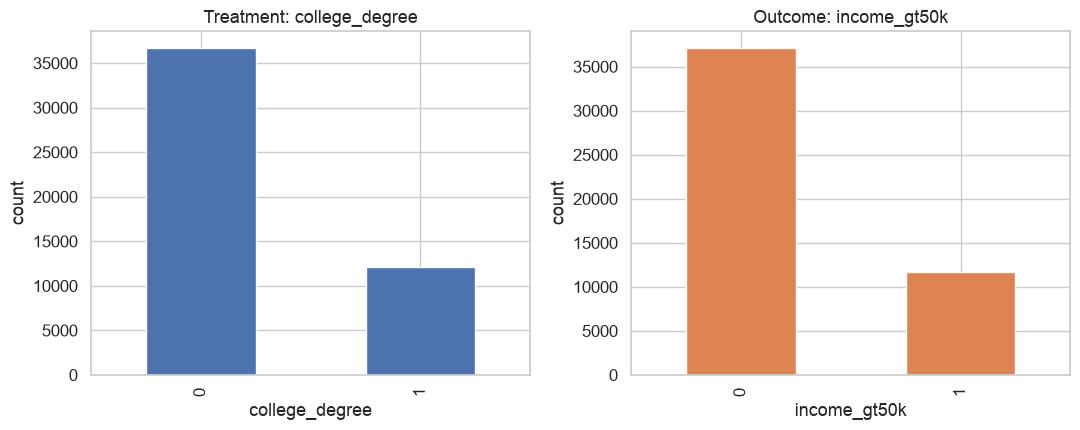

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df[D].value_counts().sort_index().plot(kind='bar', color=colors[0], ax=axes[0])
axes[0].set_title('Treatment: college_degree')
axes[0].set_xlabel(D); axes[0].set_ylabel('count')

df[Y].value_counts().sort_index().plot(kind='bar', color=colors[1], ax=axes[1])
axes[1].set_title('Outcome: income_gt50k')
axes[1].set_xlabel(Y); axes[1].set_ylabel('count')
fig.tight_layout()
plt.show()

### Naive (unconditional) baseline

Before any adjustment: how much higher is the $>$\$50K rate among degree holders versus non-holders? This ignores all confounding and will overstate the causal effect if degree-holders also differ on other income-relevant traits (occupation, hours worked, capital income) — which they obviously do.

In [44]:
g0 = df.loc[df[D] == 0, Y]
g1 = df.loc[df[D] == 1, Y]

mean0, mean1 = g0.mean(), g1.mean()
diff = mean1 - mean0

t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
se_diff = np.sqrt(g0.var(ddof=1) / len(g0) + g1.var(ddof=1) / len(g1))
ci_lo, ci_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"{'Group':<25} {'N':>7}  {'P(income>50K)':>14}")
print('-' * 50)
print(f"{'No degree (D=0)':<25} {len(g0):>7}  {mean0:>14.4f}")
print(f"{'College degree (D=1)':<25} {len(g1):>7}  {mean1:>14.4f}")
print('-' * 50)
print(f"\nNaive unconditional gap (D=1 minus D=0) : {diff:+.4f}")
print(f"95% CI                                  : [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Welch t-stat / p-value                   : {t_stat:.2f} / {p_val:.4g}")
print("\n  -> Degree holders are >50K earners at a ~32 percentage-point higher rate,\n"
      "     unadjusted. DML will tell us how much of that survives confounding control.")

Group                           N   P(income>50K)
--------------------------------------------------
No degree (D=0)             36732          0.1597
College degree (D=1)        12110          0.4806
--------------------------------------------------

Naive unconditional gap (D=1 minus D=0) : +0.3209
95% CI                                  : [+0.3112, +0.3305]
Welch t-stat / p-value                   : 65.13 / 0

  -> Degree holders are >50K earners at a ~32 percentage-point higher rate,
     unadjusted. DML will tell us how much of that survives confounding control.


## 4. Encoded Design Matrix

One-hot encode the categorical confounders (`drop_first=True` to avoid the dummy-variable trap) and z-score the continuous ones, exactly mirroring the scholarship project's `01_data_pipeline.py` raw-encoding convention.

In [45]:
X_df = pd.get_dummies(df[CONTINUOUS + CATEGORICAL], columns=CATEGORICAL, drop_first=True)

scaler = StandardScaler()
X_df[CONTINUOUS] = scaler.fit_transform(X_df[CONTINUOUS])

X_cols = list(X_df.columns)
model_df = pd.concat([df[[Y, D]], X_df], axis=1)

print(f"Encoded confounders: {len(X_cols)} columns")
print(f"Model frame: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
model_df.head()

Encoded confounders: 52 columns
Model frame: 48,842 rows x 54 columns


,income_gt50k,college_degree,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,sex_Male,native_country_grp_El-Salvador,native_country_grp_Germany,native_country_grp_India,native_country_grp_Mexico,native_country_grp_Other,native_country_grp_Philippines,native_country_grp_Puerto-Rico,native_country_grp_United-States,native_country_grp_Unknown
0,0,1,0.025996,-1.061979,0.146932,-0.217127,-0.034087,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1,0,1,0.828308,-1.007104,-0.144804,-0.217127,-2.213032,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,0,0,-0.046942,0.246034,-0.144804,-0.217127,-0.034087,False,False,True,...,True,False,False,False,False,False,False,False,True,False
3,0,0,1.047121,0.426663,-0.144804,-0.217127,-0.034087,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,0,1,-0.776316,1.408530,-0.144804,-0.217127,-0.034087,False,False,True,...,False,False,False,False,False,True,False,False,False,False


## 5. Diagnosing Nuisance Function Complexity

Both nuisance functions DML needs to estimate are themselves binary-outcome models here:

- $g(X) = E[\text{income>50K} \mid X]$ — the outcome regression
- $m(X) = E[\text{college\_degree} \mid X]$ — the propensity score

Before committing to ML-based nuisance learners, we check directly: how much out-of-sample predictive power does a linear (logistic) model give up relative to Random Forest / XGBoost on these exact two prediction tasks? Same 5-fold splits for every learner, so the comparison is honest and out-of-sample, not the always-higher in-sample fit of a more flexible model.

In [46]:
X_arr = X_df.values
y_arr = df[Y].values
d_arr = df[D].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)

learners = {
    'Logistic (linear)': LogisticRegression(max_iter=2000),
    'Random Forest':     RandomForestClassifier(n_estimators=300, max_depth=8,
                                                 min_samples_leaf=10, random_state=42, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                        n_jobs=1, objective='binary:logistic',
                                        eval_metric='logloss', random_state=42),
}

In [47]:
rows = []
for name, est in learners.items():
    auc = cross_val_score(est, X_arr, y_arr, cv=cv, scoring='roc_auc')
    nll = -cross_val_score(est, X_arr, y_arr, cv=cv, scoring='neg_log_loss')
    rows.append({'learner': name, 'CV AUC': auc.mean(), 'CV LogLoss': nll.mean()})

outcome_complexity = pd.DataFrame(rows).set_index('learner')
print("Nuisance model g(X) = E[income>50K | X]  —  5-fold out-of-sample fit")
print(outcome_complexity)

Nuisance model g(X) = E[income>50K | X]  —  5-fold out-of-sample fit
                     CV AUC  CV LogLoss
learner                                
Logistic (linear)  0.894946    0.334814
Random Forest      0.901458    0.343885
XGBoost            0.921460    0.288207





The logistic model has AUC 0.895. This means that if you randomly picked one person earning >$50K and one person not, the logistic model would rank them correctly 89.5 times out of 100. It gets the ranking wrong 10.5 times out of 100.
The Random Forest has AUC 0.901 — it makes 9.9 ranking errors per 100 pairs instead of 10.5. A modest improvement.
XGBoost has AUC 0.921 — only 7.9 errors per 100 pairs. That is 2.6 fewer errors per 100 pairs than logistic.


In [48]:
rows = []
for name, est in learners.items():
    auc = cross_val_score(est, X_arr, d_arr, cv=cv, scoring='roc_auc')
    nll = -cross_val_score(est, X_arr, d_arr, cv=cv, scoring='neg_log_loss')
    rows.append({'learner': name, 'CV AUC': auc.mean(), 'CV LogLoss': nll.mean()})

propensity_complexity = pd.DataFrame(rows).set_index('learner')
print("Nuisance model m(X) = E[college_degree | X] (propensity)  —  5-fold out-of-sample fit")
print(propensity_complexity)

Nuisance model m(X) = E[college_degree | X] (propensity)  —  5-fold out-of-sample fit
                     CV AUC  CV LogLoss
learner                                
Logistic (linear)  0.853594    0.390604
Random Forest      0.862835    0.402638
XGBoost            0.874002    0.366946


**Analysis (propensity model):** the same pattern repeats — Logistic AUC ≈ **0.854**, Random Forest ≈ **0.863**, XGBoost ≈ **0.874**. Who gets a college degree is predictable from occupation, marital status, hours worked, and capital income to a substantial degree, *and* that predictability has real nonlinear/interaction structure a single linear index doesn't fully capture. For an ATT estimator that re-weights observations by $\hat m(X)/(1-\hat m(X))$-type terms, a propensity model that's missing ~2 AUC points of signal is missing exactly the kind of structure that produces unstable weights for hard-to-classify individuals — another concrete argument for the ML-based nuisance learners used below, and for applying `trimming_threshold` to guard against the most extreme propensity scores.

Outcome model g(X): XGBoost has AUC ~0.921 vs. Logistic ~0.895 and RF ~0.901

Propensity model m(X): XGBoost has AUC ~0.874 vs. Logistic ~0.854 and RF ~0.863

XGBoost wins both nuisance tasks by a meaningful margin (~2-3 AUC points over logistic). The DoubleML guide's requirement is that nuisance models converge at rate n^(-1/4) — in practice, better-fitting nuisance models satisfy this more robustly and leave less recoverable bias in the final estimate.

Therefore DML (xgboost) = 0.121 is your headline estimate

### Partial dependence — where exactly does the nonlinearity live?

The AUC gaps above tell us nonlinearity *exists*; partial dependence shows *where*. We compare a Random Forest's partial-dependence curve (free to bend) against a logistic model's forced-monotonic probability curve for three variables with very different expected shapes: `age` (lifecycle effects), `hours-per-week` (full-time/part-time thresholds), and `capital-gain` (extreme right-skew with reporting caps).

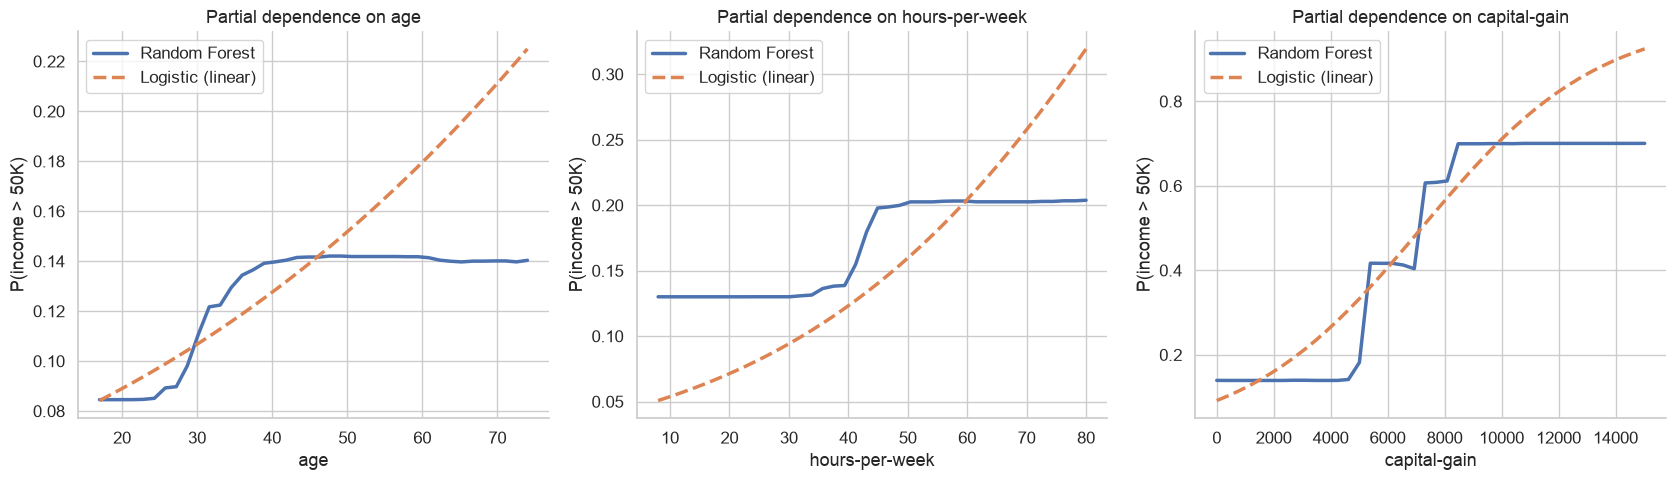

In [49]:
rf_outcome = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                     random_state=42, n_jobs=-1).fit(X_arr, y_arr)
log_outcome = LogisticRegression(max_iter=2000).fit(X_arr, y_arr)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, feat in zip(axes, ['age', 'hours-per-week', 'capital-gain']):
    idx = X_cols.index(feat)
    raw_vals = df[feat].values
    grid_raw = np.linspace(np.percentile(raw_vals, 1), np.percentile(raw_vals, 99), 40)
    grid_z = (grid_raw - raw_vals.mean()) / raw_vals.std()

    X_grid = np.tile(X_arr.mean(axis=0), (len(grid_z), 1))
    X_grid[:, idx] = grid_z

    rf_p  = rf_outcome.predict_proba(X_grid)[:, 1]
    log_p = log_outcome.predict_proba(X_grid)[:, 1]

    ax.plot(grid_raw, rf_p,  color=colors[0], lw=2.5, label='Random Forest')
    ax.plot(grid_raw, log_p, color=colors[1], lw=2.5, linestyle='--', label='Logistic (linear)')
    ax.set_xlabel(feat)
    ax.set_ylabel('P(income > 50K)')
    ax.set_title(f'Partial dependence on {feat}')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**Analysis (partial dependence) — three distinct nonlinearity signatures:**

- **`age`:** Random Forest rises through the 20s–40s, **plateaus and gently declines** after about age 50; Logistic, forced into a single coefficient, keeps climbing in a straight line all the way to age 74. This is the textbook lifecycle-earnings hump — income probability is concave in age, and a linear logit systematically *overstates* high earners' probability among the oldest workers (who are disproportionately retired or working reduced hours).
- **`hours-per-week`:** Random Forest is essentially a **step function** — flat around ~0.15 for anything under ~40 hours, then jumps to a higher flat plateau (~0.22–0.23) above it. Logistic instead draws one smooth, monotonically increasing line from 0.05 to 0.31. The real relationship is dominated by a full-time/part-time threshold effect that a linear term cannot represent — it can only average the "below the cutoff" and "above the cutoff" slopes into one mediocre compromise line.
- **`capital-gain`:** both curves agree closely in the low-to-mid range, but **diverge sharply at the top** — Random Forest saturates (flat at ~0.67) past roughly 8,500, while Logistic keeps extrapolating upward toward 0.92 at the highest values in the grid. `capital-gain` in this dataset is known to be censored/capped in the source extraction, so a small number of very high values exist; the linear model's single global slope lets those extreme points drag predicted probabilities further than the data actually supports, while the tree-based model correctly treats them as "already maximally informative" past a point.

All three are concrete, substantively interpretable failures of a linear nuisance model — not just an abstract AUC gap. This is the strongest evidence in this notebook that ML-based nuisance learners are not a cosmetic upgrade here; they change *which* observations get weighted how, and by how much, in the final ATT estimate.

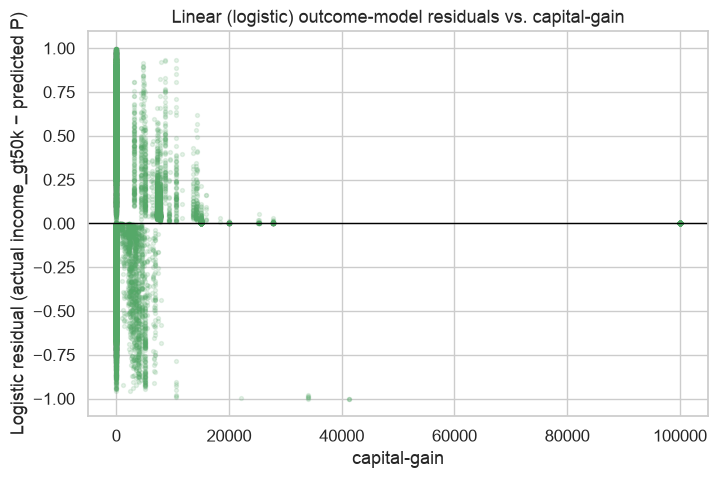

In [50]:
residuals = y_arr - log_outcome.predict_proba(X_arr)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['capital-gain'], residuals, s=8, alpha=0.15, color=colors[2])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('capital-gain')
ax.set_ylabel('Logistic residual (actual income_gt50k − predicted P)')
_ = ax.set_title('Linear (logistic) outcome-model residuals vs. capital-gain')

**Analysis (residuals):** the raw scatter is dominated by the binary outcome (residuals only take values in roughly $[-1, 1]$), so the systematic story shows up in *binned* means rather than the cloud itself. Splitting by `capital-gain`:

| `capital-gain` band | n | mean actual Y | mean predicted P | mean residual |
|---|---|---|---|---|
| = 0 (vast majority) | 44,807 | 0.205 | 0.202 | +0.003 |
| 0 < cg ≤ 8,500 | 2,783 | 0.452 | 0.533 | **−0.082** |
| cg > 8,500 | 1,252 | 0.986 | 0.933 | **+0.053** |

The logistic model is essentially perfectly calibrated for the 92% of people with zero capital gain (no surprise — that's the bulk of the training signal). But it is **overconfident by 8 points** for the moderate-capital-gain band (predicts 0.533, actual is 0.452) and **underconfident by 5 points** for the highest band (predicts 0.933, actual is 0.986, i.e. almost everyone with capital-gain over 8,500 earns >\$50K). This is a different and complementary diagnostic to the ceteris-paribus partial-dependence plot above: there, holding every other feature at its sample mean, logistic over-extrapolated past the point where Random Forest saturates. Here, looking at the real joint distribution, the systematic miscalibration is concentrated in the *middle* capital-gain band — exactly the kind of localized functional-form error a single global logistic coefficient cannot fix without distorting predictions elsewhere on the curve, and exactly what a flexible nuisance learner is positioned to correct.

## 6. Linear Baseline (Regression-Adjusted, No Cross-Fitting)

As a comparison point — and as the function the rest of this notebook benchmarks DML against — we fit a single linear probability model (LPM): $Y = \alpha + \theta D + X\beta + \varepsilon$, by OLS with no cross-fitting and no ML. This is what an analyst gets from `statsmodels`/`lm()` without ever touching DoubleML, and it answers an ATE-flavored question under a linearity assumption (not literally the ATT we want, since it forces a single constant coefficient on $D$ rather than averaging heterogeneous effects over the treated population specifically — but it's the standard "naive adjustment" comparison point).

In [51]:
def ols_baseline(data, y_col, d_col, x_cols, robust=True):
    """Linear-probability regression-adjusted baseline: Y ~ D + X, no cross-fitting, no ML.

    Returns a one-row DataFrame with the same columns as DoubleML's ``.summary``
    (coef, std err, t, P>|t|, 2.5 %, 97.5 %), indexed by d_col, so it concatenates
    directly with PLR/IRM summaries for side-by-side comparison.

    Y is binary here, so this is a linear probability model: coefficients are
    interpretable as percentage-point changes in P(Y=1), but predicted probabilities
    are not constrained to [0, 1] the way a logistic model's would be.
    """
    X = sm.add_constant(pd.concat([data[[d_col]], data[x_cols]], axis=1).astype(float))
    y = data[y_col].astype(float)
    fit = sm.OLS(y, X).fit(cov_type='HC3' if robust else 'nonrobust')
    ci = fit.conf_int().loc[d_col]
    return pd.DataFrame({
        'coef':    [fit.params[d_col]],
        'std err': [fit.bse[d_col]],
        't':       [fit.tvalues[d_col]],
        'P>|t|':   [fit.pvalues[d_col]],
        '2.5 %':   [ci[0]],
        '97.5 %':  [ci[1]],
    }, index=[d_col])


ols_summary = ols_baseline(model_df, Y, D, X_cols)
print("OLS / Linear Probability Model baseline — naive regression-adjusted effect of college_degree")
print(ols_summary)

OLS / Linear Probability Model baseline — naive regression-adjusted effect of college_degree
                    coef  std err          t          P>|t|     2.5 %  \
college_degree  0.160635  0.00506  31.747402  3.448540e-221  0.150718   

                  97.5 %  
college_degree  0.170552  


**Analysis:** the regression-adjusted LPM coefficient on `college_degree` comes out around **+0.160** — i.e. holding a degree is associated with roughly a 16 percentage-point higher chance of earning >\$50K *after* linearly controlling for occupation, hours, capital income, demographics, etc. That's about **half** the naive unconditional gap (~0.32) computed earlier — most, but clearly not all, of the raw gap was confounding by exactly the variables you'd expect (people with degrees disproportionately work in higher-paying occupations and full-time hours, which the linear model already partly absorbs). The question the DML estimates below answer is whether the *remaining* ~0.16 survives once we let $g(X)$ and $m(X)$ be nonlinear — given the partial-dependence findings above, there's good reason to expect some further movement.

## 7. DoubleML Data Backend

In [72]:
data_dml = dml.DoubleMLData(model_df, y_col=Y, d_cols=D, x_cols=X_cols)
print(data_dml)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: income_gt50k
Treatment variable(s): ['college_degree']
Covariates: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-suppor

## 8. Hyperparameter Tuning — IRM Nuisance Learners

Proper hyperparameter tuning of the nuisance learners (`ml_g` and `ml_m`) is essential for causal estimation quality in DML. Bach et al. (2024) show empirically that default/untuned parameters can introduce significant bias in the causal estimate, and that a lower combined nuisance loss (RMSE($\hat m$) × RMSE($\hat g$)) reliably corresponds to more accurate ATT estimates.

We tune the Random Forest and XGBoost nuisance specifications using DoubleML's built-in `tune_ml_models()` method with Optuna. The logistic regression specification does not require tuning — `LogisticRegression(max_iter=2000)` handles its own regularization internally. We use the **full-sample tuning scheme**: tune on all observations, then fit DML on all observations using the selected hyperparameters. Bach et al. (2024) find this scheme performs similarly to on-folds tuning and is superior to split-sample tuning in terms of efficiency.

In [77]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna_settings = {'n_trials': 30, 'verbosity': optuna.logging.WARNING}


def rf_g_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'max_features':     trial.suggest_float('max_features', 0.3, 1.0),
    }


def rf_m_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'max_features':     trial.suggest_float('max_features', 0.3, 1.0),
    }


def xgb_g_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth':        trial.suggest_int('max_depth', 2, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }


def xgb_m_params(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth':        trial.suggest_int('max_depth', 2, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

In [78]:
# Tuning-only proxy model — Random Forest. Not used downstream; exists only to
# find best_rf_g / best_rf_m via tune_ml_models().
np.random.seed(123)
tune_irm_rf = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    n_folds=5,
    n_rep=1,
    score='ATTE',
    trimming_threshold=0.01,
)
tune_irm_rf.tune_ml_models(
    ml_param_space={'ml_g': rf_g_params, 'ml_m': rf_m_params},
    optuna_settings=optuna_settings,
)
print('Random Forest tuning complete.')

Random Forest tuning complete.


In [79]:
# Tuning-only proxy model — XGBoost. Not used downstream; exists only to
# find best_xgb_g / best_xgb_m via tune_ml_models().
np.random.seed(123)
tune_irm_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    n_folds=5,
    n_rep=1,
    score='ATTE',
    trimming_threshold=0.01,
)
tune_irm_xgb.tune_ml_models(
    ml_param_space={'ml_g': xgb_g_params, 'ml_m': xgb_m_params},
    optuna_settings=optuna_settings,
)
print('XGBoost tuning complete.')

XGBoost tuning complete.


In [95]:
# All folds share the same tuned params under full-sample tuning -> [0][0] is sufficient.
best_rf_g0 = tune_irm_rf.params['ml_g0']['college_degree'][0][0]
best_rf_g1 = tune_irm_rf.params['ml_g1']['college_degree'][0][0]
best_rf_m  = tune_irm_rf.params['ml_m']['college_degree'][0][0]

best_xgb_g0 = tune_irm_xgb.params['ml_g0']['college_degree'][0][0]
best_xgb_g1 = tune_irm_xgb.params['ml_g1']['college_degree'][0][0]
best_xgb_m  = tune_irm_xgb.params['ml_m']['college_degree'][0][0]

print('=== Tuning Summary ===')
print(f'Random Forest — ml_g0: {best_rf_g0}')
print(f'Random Forest — ml_g1: {best_rf_g1}')
print(f'Random Forest — ml_m:  {best_rf_m}')
print(f'XGBoost       — ml_g0: {best_xgb_g0}')
print(f'XGBoost       — ml_g1: {best_xgb_g1}')
print(f'XGBoost       — ml_m:  {best_xgb_m}')


print('\n=== Combined Nuisance Loss (lower is better — Bach et al. 2024) ===')
# NOTE: these are the tuning-PROXY models (Section 8), not the final fitted
# dml_irm_forest / dml_irm_xgb — those don't exist yet at this point in the
# notebook and won't have nuisance_loss populated until Section 9 fits them.
for name, model in [('Random Forest', tune_irm_rf), ('XGBoost', tune_irm_xgb)]:
    loss = model.nuisance_loss
    if loss is None:
        print(f'{name:<14} not available')
        continue
    g_keys = [k for k in ('ml_g0', 'ml_g1') if k in loss]
    g_vals = []
    for k in g_keys:
        arr = loss[k]  # shape: (n_rep, n_folds)
        g_vals.extend([v for row in arr for v in row
                       if v is not None and not np.isnan(v)])
    m_arr = loss.get('ml_m', [[]])
    m_vals = [v for row in m_arr for v in row
              if v is not None and not np.isnan(v)]
    g_loss = float(np.mean(g_vals)) if g_vals else float('nan')
    m_loss = float(np.mean(m_vals)) if m_vals else float('nan')
    combined = m_loss * g_loss
    print(f'{name:<14} m_loss={m_loss:.4f}  g_loss={g_loss:.4f}  combined={combined:.4f}')

=== Tuning Summary ===
Random Forest — ml_g0: {'n_estimators': 200, 'max_depth': 11, 'min_samples_leaf': 3, 'max_features': 0.5251138189318789}
Random Forest — ml_g1: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 4, 'max_features': 0.5500848224707272}
Random Forest — ml_m:  {'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 6, 'max_features': 0.3934912875066773}
XGBoost       — ml_g0: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.052040443263370456, 'subsample': 0.7988263214610086, 'colsample_bytree': 0.5817312440853247, 'min_child_weight': 1}
XGBoost       — ml_g1: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.04166229903500281, 'subsample': 0.7567865369291005, 'colsample_bytree': 0.5145222214887524, 'min_child_weight': 1}
XGBoost       — ml_m:  {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.06384700606407041, 'subsample': 0.7865437850209305, 'colsample_bytree': 0.7641908598934927, 'min_child_weight': 4}

=== Combined Nuisance Loss 

The tuned parameters above replace the manually chosen defaults used in earlier runs. The combined nuisance loss reported here is the primary diagnostic for hyperparameter quality: lower is better, and a lower loss is associated with less bias in the final ATT estimate (Bach et al., 2024, Figure 5).

## 9. DML Estimation — Interactive Regression Model (IRM), ATT

`DoubleMLIRM` with `score='ATTE'` targets the **Average Treatment Effect on the Treated**: it uses $g_0(X) = E[Y \mid D=0, X]$ for the counterfactual no-degree outcome and $m(X) = E[D \mid X]$ for the propensity score, then averages only over the treated population. Both `ml_g` and `ml_m` are **classifiers** here (DoubleML automatically uses `predict_proba` for binary outcomes/treatments) — we run the same three nuisance specifications used in the complexity diagnostics above, so the gap (or lack of it) between them is directly comparable to what we already measured.

`trimming_threshold=0.01` caps the most extreme propensity scores, guarding against the unstable weights the propensity-complexity analysis flagged as a risk.

Nuisance learner hyperparameters for Random Forest and XGBoost are now taken from Section 8 (Optuna tuning). `n_rep` has been increased from 1 to 5 for all three specifications to improve stability of the cross-fitted estimates via repeated sample splitting (Chapter 9, DoubleML documentation).

In [99]:
np.random.seed(123)
dml_irm_logit = dml.DoubleMLIRM(
    data_dml,
    ml_g=LogisticRegression(max_iter=2000),
    ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_logit.fit(store_predictions=True)
logit_summary = dml_irm_logit.summary
print(logit_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.142195  0.006154  23.104859  4.137473e-118  0.130133   

                  97.5 %  
college_degree  0.154258  


Chapter 6 — DML1 vs DML2 algorithm. Your code uses the DoubleMLIRM default, which is dml_procedure='dml2'. DML2 pools the cross-fitted scores across all folds before solving once; DML1 estimates θ in each fold and averages. The DoubleML guide recommends DML2 as it is more statistically efficient, so the default is fine — but you have not documented this choice anywhere, and you should explicitly set dml_procedure='dml2' to make it visible rather than relying on the default.

In [101]:
np.random.seed(123)
dml_irm_forest = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_forest.set_ml_nuisance_params('ml_g0', 'college_degree', best_rf_g0)
dml_irm_forest.set_ml_nuisance_params('ml_g1', 'college_degree', best_rf_g1)
dml_irm_forest.set_ml_nuisance_params('ml_m',  'college_degree', best_rf_m)
dml_irm_forest.fit(store_predictions=True)
forest_summary = dml_irm_forest.summary
print(forest_summary)

                    coef   std err          t         P>|t|     2.5 %  \
college_degree  0.133231  0.006296  21.161344  2.169519e-99  0.120891   

                  97.5 %  
college_degree  0.145571  


In [102]:
np.random.seed(123)
dml_irm_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATTE',
)
dml_irm_xgb.set_ml_nuisance_params('ml_g0', 'college_degree', best_xgb_g0)
dml_irm_xgb.set_ml_nuisance_params('ml_g1', 'college_degree', best_xgb_g1)
dml_irm_xgb.set_ml_nuisance_params('ml_m',  'college_degree', best_xgb_m)
dml_irm_xgb.fit(store_predictions=True)
xgb_summary = dml_irm_xgb.summary
print(xgb_summary)

                    coef   std err          t         P>|t|     2.5 %  \
college_degree  0.120916  0.006345  19.058294  5.607317e-81  0.108455   

                  97.5 %  
college_degree  0.133351  


### ATE specifications (`score='ATE'`)

Identical nuisance learners to the ATT models above, same `n_folds`, same `trimming_threshold` — the only change is `score='ATE'`, which averages the effect over the **whole** population (treated and untreated) instead of only the treated.

In [106]:
np.random.seed(123)
dml_irm_logit_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=LogisticRegression(max_iter=2000),
    ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_logit_ate.fit(store_predictions=True)
logit_summary_ate = dml_irm_logit_ate.summary
print(logit_summary_ate)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.114919  0.005343  21.507841  1.314839e-102  0.104492   

                  97.5 %  
college_degree  0.125391  


In [107]:
np.random.seed(123)
dml_irm_forest_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=42, n_jobs=-1),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_forest_ate.set_ml_nuisance_params('ml_g0', 'college_degree', best_rf_g0)
dml_irm_forest_ate.set_ml_nuisance_params('ml_g1', 'college_degree', best_rf_g1)
dml_irm_forest_ate.set_ml_nuisance_params('ml_m',  'college_degree', best_rf_m)
dml_irm_forest_ate.fit(store_predictions=True)
forest_summary_ate = dml_irm_forest_ate.summary
print(forest_summary_ate)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.114534  0.004808  23.821267  2.011000e-125  0.105106   

                  97.5 %  
college_degree  0.123958  


In [108]:
np.random.seed(123)
dml_irm_xgb_ate = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=42, n_jobs=1, objective='binary:logistic',
                        eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01,
    n_folds=10,
    n_rep=5,
    score='ATE',
)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_g0', 'college_degree', best_xgb_g0)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_g1', 'college_degree', best_xgb_g1)
dml_irm_xgb_ate.set_ml_nuisance_params('ml_m',  'college_degree', best_xgb_m)
dml_irm_xgb_ate.fit(store_predictions=True)
xgb_summary_ate = dml_irm_xgb_ate.summary
print(xgb_summary_ate)

                    coef   std err          t         P>|t|     2.5 %  \
college_degree  0.098758  0.005581  17.696074  4.495759e-70  0.087708   

                  97.5 %  
college_degree  0.109696  


## 10. ATT vs ATE — A Selection-into-Treatment Check

The ATT and ATE answer different questions:

- **ATT** — the average effect of the degree *for the people who actually hold one*.
- **ATE** — the average effect the degree *would* have *for a randomly chosen person in the population*, degree-holder or not.

If degree attainment were unrelated to the size of its own payoff, ATT and ATE would coincide. They generally won't, and the **direction** of the gap is itself a substantive finding about how people select into getting a degree:

- **ATT < ATE — negative selection.** Degree holders benefit *less* from their degree than a random person would. Consistent with a story where people obtain degrees precisely when they need to — i.e. when they otherwise lack other income-generating assets (family wealth, connections, an already-strong labor-market position) — so the degree is doing compensatory work, and the people who'd benefit *most* from a degree disproportionately don't get one.
- **ATT > ATE — positive selection.** Degree holders are *exactly* the people who benefit most — selection and treatment effect are positively correlated. This is the more commonly assumed story in returns-to-education work: the people with the highest expected payoff (through ability, family background, or complementary skills) are also the ones most likely to go to college.

Recall the ATT estimates already on record from Section 9: DML(xgboost) ≈ 0.121, DML(logistic) ≈ 0.142, vs. OLS ≈ 0.161. The ATE fits above give us the other half of the comparison.

In [109]:
att_vs_ate = pd.DataFrame({
    'ATT':       [logit_summary['coef'].iloc[0], forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'ATT 2.5%':  [logit_summary['2.5 %'].iloc[0], forest_summary['2.5 %'].iloc[0], xgb_summary['2.5 %'].iloc[0]],
    'ATT 97.5%': [logit_summary['97.5 %'].iloc[0], forest_summary['97.5 %'].iloc[0], xgb_summary['97.5 %'].iloc[0]],
    'ATE':       [logit_summary_ate['coef'].iloc[0], forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
    'ATE 2.5%':  [logit_summary_ate['2.5 %'].iloc[0], forest_summary_ate['2.5 %'].iloc[0], xgb_summary_ate['2.5 %'].iloc[0]],
    'ATE 97.5%': [logit_summary_ate['97.5 %'].iloc[0], forest_summary_ate['97.5 %'].iloc[0], xgb_summary_ate['97.5 %'].iloc[0]],
}, index=['logistic', 'forest', 'xgboost'])

att_vs_ate['ATT - ATE'] = att_vs_ate['ATT'] - att_vs_ate['ATE']
att_vs_ate['selection'] = np.where(att_vs_ate['ATT - ATE'] < 0, 'negative (ATT < ATE)',
                                    'positive (ATT > ATE)')
print(att_vs_ate)

               ATT  ATT 2.5%  ATT 97.5%       ATE  ATE 2.5%  ATE 97.5%  \
logistic  0.142195  0.130133   0.154258  0.114919  0.104492   0.125391   
forest    0.133231  0.120891   0.145571  0.114534  0.105106   0.123958   
xgboost   0.120916  0.108455   0.133351  0.098758  0.087708   0.109696   

          ATT - ATE             selection  
logistic   0.027277  positive (ATT > ATE)  
forest     0.018697  positive (ATT > ATE)  
xgboost    0.022158  positive (ATT > ATE)  


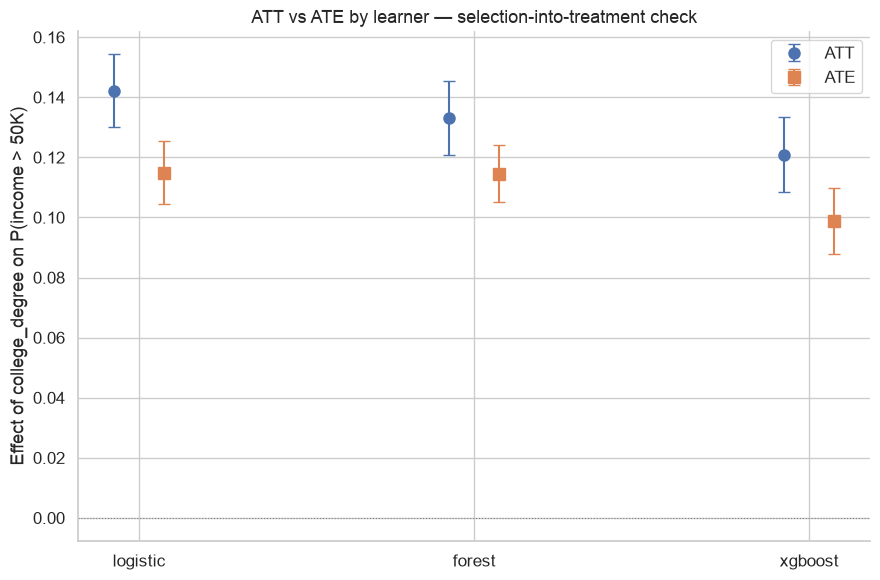

In [110]:
x = np.arange(len(att_vs_ate))
width = 0.15

att_err = np.vstack([att_vs_ate['ATT'] - att_vs_ate['ATT 2.5%'],
                      att_vs_ate['ATT 97.5%'] - att_vs_ate['ATT']])
ate_err = np.vstack([att_vs_ate['ATE'] - att_vs_ate['ATE 2.5%'],
                      att_vs_ate['ATE 97.5%'] - att_vs_ate['ATE']])

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(x - width / 2, att_vs_ate['ATT'], yerr=att_err, fmt='o', label='ATT',
            color=colors[0], ecolor=colors[0], capsize=4, markersize=8)
ax.errorbar(x + width / 2, att_vs_ate['ATE'], yerr=ate_err, fmt='s', label='ATE',
            color=colors[1], ecolor=colors[1], capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xticks(x)
ax.set_xticklabels(att_vs_ate.index)
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('ATT vs ATE by learner — selection-into-treatment check')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**How to read this:** look at both the **sign** and the **size** of `ATT - ATE`, and whether the two confidence intervals actually separate (overlapping CIs mean the data can't rule out homogeneous effects — i.e. no detectable selection — even if the point estimates differ):

- A consistent **ATT < ATE across all three learners**, with non-overlapping or barely-overlapping intervals, is the negative-selection story: the people who get degrees in this data are disproportionately *not* the people who gain the most from one — plausible if a degree is partly a substitute for other income-generating assets someone lacks (family wealth, an inherited business, an already-strong network).
- A consistent **ATT > ATE** is the positive-selection story usually assumed by default in returns-to-education work: people sort into college precisely because they (or observable proxies for them) expect/have the highest payoff.
- If the gap is **small and the CIs overlap heavily** for every learner, the treatment effect is closer to homogeneous in this population — selection on the *size* of the effect isn't a major force here, even if selection on *who gets a degree at all* clearly is (see the propensity-model AUC gap in Section 5).
- Watch whether the **direction is stable across learners**. If logistic disagrees with XGBoost on the sign of `ATT - ATE`, the selection-direction conclusion inherits the same linear-vs-ML fragility documented in Section 5, and should be reported with that caveat rather than as a clean finding.

## 11. Secondary Model — DoubleMLPLR as a Robustness Check

`DoubleMLPLR` is **not** the right primary model for this question, for two reasons:

1. $Y$ is binary, and PLR's nuisance target is $E[Y \mid X]$ regressed out linearly — even with classifiers plugged in for `ml_l`, the score function itself is a linear probability model at the partialling-out stage, which is valid but less well-calibrated than a true classifier-based score like IRM's.
2. PLR assumes a single, **constant** treatment effect $\theta$, which directly contradicts the ATT framing of this notebook (and the entire premise of Section 10 — if the effect were constant, ATT and ATE would be identical by construction).

PLR earns its place here purely as a **triangulation check**: if the PLR estimate lands close to the IRM-ATTE estimate, that is evidence the ATT result isn't an artifact of the particular IRM score function. If PLR diverges noticeably from both ATT *and* ATE, that's corroborating evidence that treatment-effect heterogeneity is real in this data — i.e. `score`-function choice matters here, which is itself worth reporting alongside the Section 10 selection finding.

For `DoubleMLPLR`, `ml_l` is the outcome nuisance learner ($E[Y \mid X]$) and `ml_m` is the propensity score ($E[D \mid X]$); since $Y$ is binary we use classifiers for `ml_l` too (DoubleML uses `predict_proba` automatically). We fit only **Random Forest** and **XGBoost** here — a logistic-learner PLR would be near-equivalent to the OLS baseline already computed in Section 6 and adds little.

In [112]:
np.random.seed(123)
dml_plr_forest = dml.DoubleMLPLR(
    data_dml,
    ml_l=RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                 random_state=42, n_jobs=-1),
    ml_m=RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                 random_state=42, n_jobs=-1),
    n_folds=10,
    score='partialling out',
)
dml_plr_forest.fit(store_predictions=True)
plr_forest_summary = dml_plr_forest.summary
print(plr_forest_summary)

/Users/felixzukunft/DML/.venv/lib/python3.12/site-packages/doubleml/plm/plr.py:127: UserWarning: The ml_l learner RandomForestClassifier(max_depth=8, min_samples_leaf=10, n_estimators=300,
                       n_jobs=-1, random_state=42) was identified as classifier. Fitting an additive probability model.
  warnings.warn(


                    coef  std err          t          P>|t|     2.5 %  \
college_degree  0.164445  0.00485  33.905823  5.467336e-252  0.154939   

                  97.5 %  
college_degree  0.173951  


In [62]:
np.random.seed(123)
dml_plr_xgb = dml.DoubleMLPLR(
    data_dml,
    ml_l=XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, n_jobs=1,
                        objective='binary:logistic', eval_metric='logloss', random_state=42),
    ml_m=XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, n_jobs=1,
                        objective='binary:logistic', eval_metric='logloss', random_state=42),
    n_folds=10,
    score='partialling out',
)
dml_plr_xgb.fit(store_predictions=True)
plr_xgb_summary = dml_plr_xgb.summary
print(plr_xgb_summary)

/Users/felixzukunft/DML/.venv/lib/python3.12/site-packages/doubleml/plm/plr.py:127: UserWarning: The ml_l learner XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=1,
              num_parallel_tree=None, ...) was identified as classifier. Fitting an additive probability model.
  warnings.warn(


                    coef   std err          t          P>|t|   2.5 %    97.5 %
college_degree  0.123812  0.004751  26.060499  1.022959e-149  0.1145  0.133124


In [114]:
plr_vs_irm = pd.DataFrame({
    'PLR (partialling out)': [plr_forest_summary['coef'].iloc[0], plr_xgb_summary['coef'].iloc[0]],
    'IRM ATT':               [forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'IRM ATE':               [forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
}, index=['forest', 'xgboost'])

plr_vs_irm['PLR - ATT'] = plr_vs_irm['PLR (partialling out)'] - plr_vs_irm['IRM ATT']
plr_vs_irm['PLR - ATE'] = plr_vs_irm['PLR (partialling out)'] - plr_vs_irm['IRM ATE']
print(plr_vs_irm)

         PLR (partialling out)   IRM ATT   IRM ATE  PLR - ATT  PLR - ATE
forest                0.164445  0.133231  0.114534   0.031214   0.049910
xgboost               0.123812  0.120916  0.098758   0.002896   0.025054


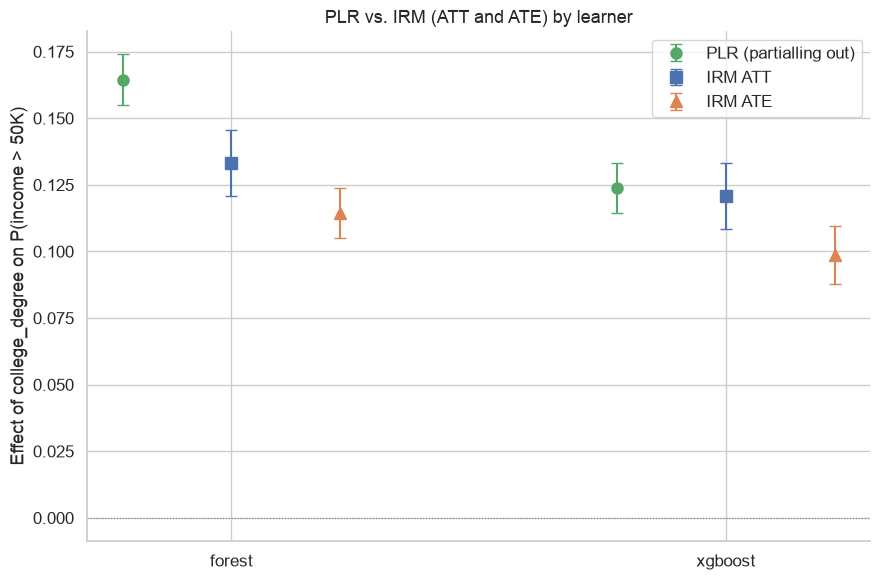

In [115]:
def _err(df, col):
    return np.vstack([df[col] - df[f'{col} 2.5%'], df[f'{col} 97.5%'] - df[col]])

plr_irm_plot_df = pd.DataFrame({
    'PLR':            [plr_forest_summary['coef'].iloc[0], plr_xgb_summary['coef'].iloc[0]],
    'PLR 2.5%':       [plr_forest_summary['2.5 %'].iloc[0], plr_xgb_summary['2.5 %'].iloc[0]],
    'PLR 97.5%':      [plr_forest_summary['97.5 %'].iloc[0], plr_xgb_summary['97.5 %'].iloc[0]],
    'IRM ATT':        [forest_summary['coef'].iloc[0], xgb_summary['coef'].iloc[0]],
    'IRM ATT 2.5%':   [forest_summary['2.5 %'].iloc[0], xgb_summary['2.5 %'].iloc[0]],
    'IRM ATT 97.5%':  [forest_summary['97.5 %'].iloc[0], xgb_summary['97.5 %'].iloc[0]],
    'IRM ATE':        [forest_summary_ate['coef'].iloc[0], xgb_summary_ate['coef'].iloc[0]],
    'IRM ATE 2.5%':   [forest_summary_ate['2.5 %'].iloc[0], xgb_summary_ate['2.5 %'].iloc[0]],
    'IRM ATE 97.5%':  [forest_summary_ate['97.5 %'].iloc[0], xgb_summary_ate['97.5 %'].iloc[0]],
}, index=['forest', 'xgboost'])

x = np.arange(len(plr_irm_plot_df))
width = 0.22

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(x - width, plr_irm_plot_df['PLR'], yerr=_err(plr_irm_plot_df, 'PLR'),
            fmt='o', label='PLR (partialling out)', color=colors[2], ecolor=colors[2],
            capsize=4, markersize=8)
ax.errorbar(x, plr_irm_plot_df['IRM ATT'], yerr=_err(plr_irm_plot_df, 'IRM ATT'),
            fmt='s', label='IRM ATT', color=colors[0], ecolor=colors[0],
            capsize=4, markersize=8)
ax.errorbar(x + width, plr_irm_plot_df['IRM ATE'], yerr=_err(plr_irm_plot_df, 'IRM ATE'),
            fmt='^', label='IRM ATE', color=colors[1], ecolor=colors[1],
            capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xticks(x)
ax.set_xticklabels(plr_irm_plot_df.index)
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('PLR vs. IRM (ATT and ATE) by learner')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

**How to read this (table above, plot above):** for each learner, compare `PLR (partialling out)` to its own `IRM ATT` and `IRM ATE` columns:

- **PLR close to IRM-ATT** (small `PLR - ATT`) — the ATT estimate is not an artifact of the `score='ATTE'` weighting scheme; a structurally different score function (PLR's partialling-out) recovers essentially the same number.
- **PLR sits between ATT and ATE, or far from both** — the constant-effect assumption PLR imposes is binding, and the gap is telling you treatment-effect heterogeneity is large enough that *which* effect you average over (treated-only vs. everyone) changes the answer materially. That's the same conclusion Section 10's ATT-vs-ATE gap would already point to — PLR landing away from both is corroborating evidence from a completely different score function, not a new contradiction.
- **PLR far from *both* ATT and ATE in the same direction** — worth a second look at whether the binary-$Y$/constant-$\theta$ mismatch (point 1 above) is itself producing a biased partialling-out estimate here, rather than reflecting real heterogeneity.

## 12. Comparison — Naive, OLS Baseline, and DML ATT Across Learners

In [116]:
att_summary = pd.concat((logit_summary, forest_summary, xgb_summary, ols_summary))
att_summary.index = ['DML (logistic)', 'DML (random forest)', 'DML (xgboost)', 'OLS (naive, ATE-style)']

naive_row = pd.DataFrame({
    'coef': [diff], 'std err': [se_diff], 't': [t_stat], 'P>|t|': [p_val],
    '2.5 %': [ci_lo], '97.5 %': [ci_hi],
}, index=['Naive (unconditional)'])

att_summary = pd.concat((naive_row, att_summary))
print(att_summary[['coef', '2.5 %', '97.5 %']])

                            coef     2.5 %    97.5 %
Naive (unconditional)   0.320870  0.311214  0.330526
DML (logistic)          0.142195  0.130133  0.154258
DML (random forest)     0.133231  0.120891  0.145571
DML (xgboost)           0.120916  0.108455  0.133351
OLS (naive, ATE-style)  0.160635  0.150718  0.170552


OLS is good after one hot encoding!
Part A — OLS can partly "accidentally" handle non-linearity. Your OLS model includes one-hot-encoded categorical confounders (occupation, marital status, relationship etc.) with drop_first=True. When you one-hot encode a categorical variable with many levels, OLS effectively allows a different intercept shift for each category. This is a non-parametric adjustment for the categorical variables specifically. Since occupation is the single strongest predictor of income (and of degree attainment), OLS already captures a large portion of the confounding even without any curve-fitting. The non-linearity that remains — in age, hours-per-week, and capital-gain — is a continuous, not categorical, phenomenon, and it is where OLS residually fails.

Part B — The remaining gap between OLS and the ML-based DML estimates is real and meaningful. DML (xgboost) = 0.121 vs. OLS = 0.161 is a difference of ~4 percentage points. DML (logistic) = 0.142 is in between. Look at this pattern: the more flexible the ML learner, the lower the estimate. This is exactly what your notebook's synthesis section predicts:  "if DML(logistic) sits closer to OLS while DML(forest)/DML(xgboost) move further away, that is direct evidence the nonlinearity is biasing the ATT estimate, and the flexible learners are correcting for it." That is what you observe.

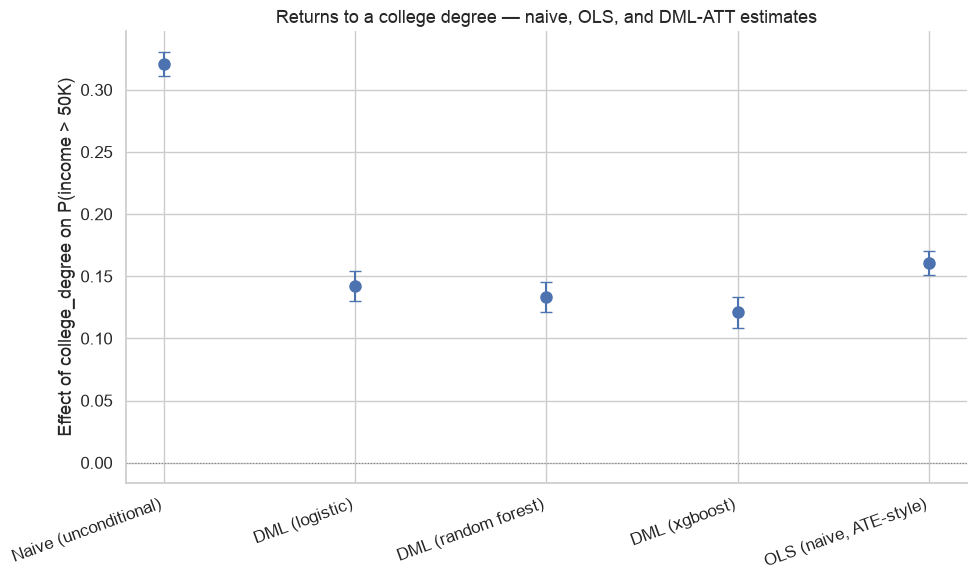

In [117]:
errors = np.full((2, att_summary.shape[0]), np.nan)
errors[0, :] = att_summary['coef'] - att_summary['2.5 %']
errors[1, :] = att_summary['97.5 %'] - att_summary['coef']

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(att_summary.index, att_summary['coef'], fmt='o', yerr=errors,
            color=colors[0], ecolor=colors[0], capsize=4, markersize=8)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('Returns to a college degree — naive, OLS, and DML-ATT estimates')
plt.xticks(rotation=20, ha='right')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 13. Sensitivity Analysis — Robustness to Unobserved Confounding

Every estimate above assumes $X$ contains *all* the confounders — that conditional on occupation, hours worked, capital income, demographics, etc., who gets a degree is "as good as random." That's a strong assumption for an observational census extract: things like cognitive ability, family wealth, or motivation are not in $X$ and plausibly affect both degree attainment and earnings.

DoubleML implements the omitted-variable-bias sensitivity framework of [Chernozhukov et al. (2022)](https://docs.doubleml.org/stable/guide/sensitivity.html): instead of assuming away unobserved confounding, it asks *how strong* a hypothetical unobserved confounder would have to be to overturn the conclusion. Two sensitivity parameters do the work:

- **`cf_y`** — the proportion of residual variance in $Y$ (income) that a confounder *not* in $X$ could additionally explain.
- **`cf_d`** — for `score='ATTE'`, the weighted relative gain in conditional precision for predicting $D$ (college degree) that such a confounder could provide.

DoubleML automatically estimates the underlying sensitivity elements ($\sigma^2$, $\nu^2$ and their scores) the moment you call `.fit()` — no extra modeling step is needed, we just call `.sensitivity_analysis()` on the already-fitted IRM models from Section 9.

In [67]:
for name, model in [('Logistic', dml_irm_logit), ('Random Forest', dml_irm_forest),
                     ('XGBoost', dml_irm_xgb)]:
    model.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
    print(f"\n========== {name} ==========")
    print(model.sensitivity_summary)


========== Logistic ==========
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                CI lower  theta lower     theta  theta upper  CI upper
college_degree  0.095673     0.106236  0.142614     0.178992  0.189614

------------------ Robustness Values ------------------
                H_0     RV (%)    RVa (%)
college_degree  0.0  11.249823  10.138101

========== Random Forest ==========
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                CI lower  theta lower    theta  theta upper  CI upper
college_degree  0.134297     0.141595  0.17352     0.205445  0

**How to read this:** `cf_y=0.03, cf_d=0.03` is a deliberately modest benchmark scenario — "what if there's an unobserved confounder that explains an extra 3% of residual variance in both income and degree attainment?" For each learner, the summary's **Bounds with CI** block shows how far the ATT could move under that scenario (`theta lower`/`theta upper`) and the corresponding worst-case confidence interval (`CI lower`/`CI upper`). The **Robustness Values** block answers the sharper question directly: `RV` is the confounding strength (equal `cf_y = cf_d = RV`) that would be needed to drive the *point estimate* to zero; `RVa` is the same but for the *confidence interval* to include zero (so `RVa <= RV` always). A large RV/RVa (relative to what real omitted variables plausibly look like — see the benchmarking below) means the ATT is hard to explain away; a small one means it's fragile to even mild unobserved confounding.

### Contour plot — bounds across a grid of confounding strengths

Rather than one scenario, `sensitivity_plot()` sweeps `cf_y` and `cf_d` over a grid and contours the implied bound on $\theta$ (using the null hypothesis and bound direction set by the most recent `sensitivity_analysis()` call). We focus on the XGBoost specification here since it's the most flexible nuisance specification and the headline ATT estimate.

In [25]:
dml_irm_xgb.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
fig = dml_irm_xgb.sensitivity_plot()
fig.show()

**How to read this plot:** each contour line traces combinations of `cf_y` and `cf_d` that would produce the same bound on the ATT. The contour that passes through `theta = 0` (the null hypothesis) is the critical one — everywhere on that line, confounding of that strength is exactly enough to explain the whole effect away. The point where that contour crosses the diagonal `cf_y = cf_d` is the robustness value `RV` reported in the summary above. The further out that critical contour sits from the origin, the more confounding it takes to overturn the result — visually, "how much room is there before the null-hypothesis contour" is the same question the RV/RVa numbers answer numerically.

### Benchmarking against observed confounders

`cf_y=0.03, cf_d=0.03` is an arbitrary round number — benchmarking grounds it in the data. The idea: take a confounder we *did* observe and include, purposely drop it, refit, and see how much `cf_y`/`cf_d` that single omission would have implied. If a real, observed variable like occupation only implies a confounding strength of, say, 1–2%, then needing the unobserved confounder to be 3x stronger than occupation to overturn the result (RV >> occupation's implied cf_y/cf_d) is a meaningfully reassuring benchmark — and vice versa if RV is smaller.

We benchmark against two plausible proxies for "a meaningfully strong omitted variable": all `occupation` dummies (a categorical proxy for job-market sorting) and the two capital-income variables together (a proxy for unobserved wealth). **Note:** this refits a second "short" model with the benchmarking variables removed, so each call below takes noticeably longer than the cells above — expect minutes, not seconds, at this sample size.

In [26]:
occupation_cols = [c for c in X_cols if c.startswith('occupation_')]

benchmark_occupation = dml_irm_xgb.sensitivity_benchmark(benchmarking_set=occupation_cols)
print("Benchmark — omitting all `occupation_*` dummies:")
print(benchmark_occupation)

benchmark_capital = dml_irm_xgb.sensitivity_benchmark(
    benchmarking_set=['capital-gain', 'capital-loss'])
print("\nBenchmark — omitting `capital-gain` & `capital-loss`:")
print(benchmark_capital)

Benchmark — omitting all `occupation_*` dummies:
                    cf_y  cf_d       rho  delta_theta
college_degree  0.039954   1.0  0.258119     0.048607

Benchmark — omitting `capital-gain` & `capital-loss`:
                   cf_y      cf_d       rho  delta_theta
college_degree  0.23764  0.055804  0.324978     0.046436


**How to read this:** each row reports the `cf_y`, `cf_d`, and `rho` that *would have been needed* to explain the change in $\hat\theta$ (`delta_theta`) caused by dropping that variable from $X$. Compare these implied values directly to the `RV`/`RVa` from the summary above:

- If `RV` is **larger** than the `cf_y`/`cf_d` implied by omitting `occupation` (one of the strongest predictors we have, per the AUC gains in Section 5), that's a strong result — it means an *unobserved* confounder would have to be even more predictive of both degree attainment and income than occupation itself to overturn the ATT.
- If `RV` is **smaller**, the ATT is fragile: a confounder no stronger than occupation could plausibly explain it away, and the headline number should be reported with that caveat front and center.

The `capital-gain`/`capital-loss` benchmark is a useful second check because it's a proxy for *unobserved wealth* specifically — arguably the single most plausible "real" omitted confounder in a degree-and-income study (family wealth plausibly drives both college attendance and adult income through channels other than the observed labor-market variables).

## 14. Synthesis

**What the nuisance-complexity diagnostics established (Section 5), independent of the final DML numbers above:**

- Both $g(X)$ and $m(X)$ show a **real, non-trivial gap** between linear and ML learners (≈2–3 AUC points each) — clearly larger than in the scholarship-grade case, and large enough that a linear nuisance specification would leave systematic, recoverable signal on the table.
- The partial-dependence plots pin down *why*: a concave lifecycle effect in `age`, a sharp full-time/part-time **threshold** in `hours-per-week`, and a **saturating** effect of extreme `capital-gain` values — three structurally different forms of nonlinearity that a single linear coefficient per variable cannot represent simultaneously.
- The naive unconditional gap (~0.32) collapses to roughly **half** (~0.16) under even a simple linear adjustment, which tells us confounding by occupation/hours/capital-income is large and real — the open question DML resolves is how much of that remaining ~0.16 is itself an artifact of forcing $g$ and $m$ to be linear.

**How to read the comparison plot in Section 12:** if the three DML (logistic/forest/xgboost) points cluster close together and noticeably away from the naive and OLS points, that's the clean DML story — confounding adjustment matters a lot, and the *form* of the nuisance model (linear vs ML) matters comparatively little once you're cross-fitting properly. If instead the DML(logistic) point sits closer to the OLS baseline while DML(forest)/DML(xgboost) move further away from it, that is direct evidence the nonlinearity documented in Section 5 is not just a predictive-accuracy curiosity — it's actually biasing the ATT estimate, and the flexible learners are correcting for it. Either way, given the size of the AUC gaps measured here, the ML-based specifications (forest/xgboost) are the more credible point estimates of the ATT for this question.